In [19]:
import pandas as pd
data=pd.read_csv('healthcare/diseased.csv')
data.tail()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
1995,1,1,0,0,1,0,0,0,1,1,Alcoholic hepatitis
1996,1,0,0,0,1,1,1,0,1,1,Alcoholic hepatitis
1997,1,0,0,1,0,0,0,0,0,1,Alcoholic hepatitis
1998,0,0,0,0,1,1,0,0,0,1,Alcoholic hepatitis
1999,0,0,0,1,1,1,0,0,0,1,Alcoholic hepatitis


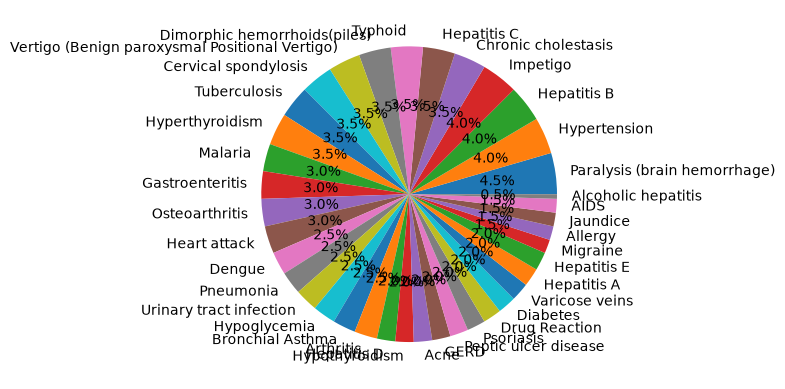

In [20]:
from matplotlib import pyplot as plt
ax=data['disease'].value_counts().plot.pie(autopct='%1.1f%%')

In [21]:
data['disease'].value_counts()

disease
Paralysis (brain hemorrhage)                      90
Hypertension                                      80
Hepatitis B                                       80
Impetigo                                          80
Chronic cholestasis                               70
Hepatitis C                                       70
Typhoid                                           70
Dimorphic hemorrhoids(piles)                      70
Vertigo (Benign paroxysmal Positional Vertigo)    70
Cervical spondylosis                              70
Tuberculosis                                      70
Hyperthyroidism                                   70
Malaria                                           60
Gastroenteritis                                   60
Osteoarthritis                                    60
Heart attack                                      60
Dengue                                            50
Pneumonia                                         50
Urinary tract infection               

In [22]:
data.isnull().sum()

fever          0
headache       0
nausea         0
vomiting       0
fatigue        0
joint_pain     0
skin_rash      0
cough          0
weight_loss    0
yellow_eyes    0
disease        0
dtype: int64

In [23]:
filtered_disease=data[data['disease']=='Diabetes']
filtered_disease.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
1710,1,0,1,0,0,0,0,0,0,1,Diabetes
1711,1,0,0,1,0,0,0,0,0,1,Diabetes
1712,1,0,0,1,0,0,0,0,1,1,Diabetes
1713,1,0,1,0,1,0,0,0,0,1,Diabetes
1714,1,0,0,0,0,1,1,0,0,1,Diabetes


Text(0.5, 1.0, 'Disease class distribution before resampling')

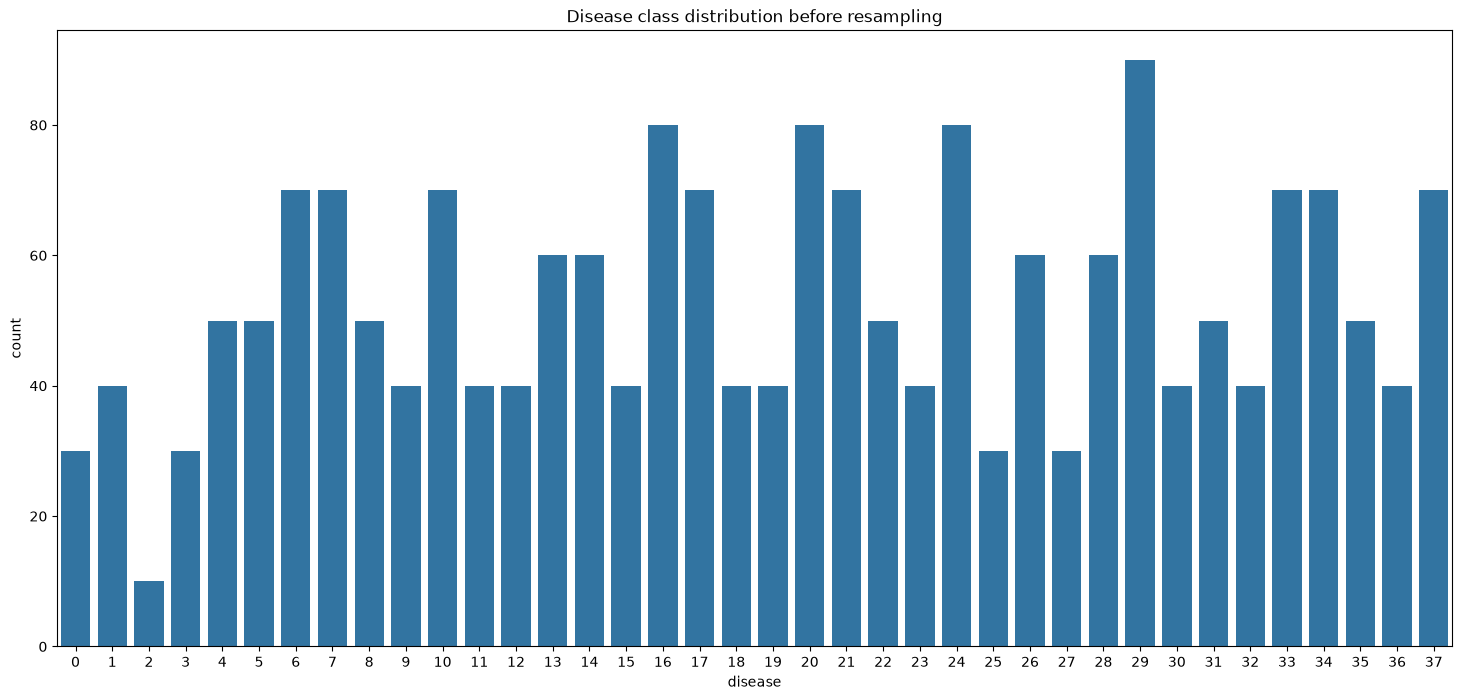

In [24]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# convert single column/list of categories to numbers(0 to num_of_categories-1)
data['disease']=encoder.fit_transform(data['disease'])
# fit_transform cannot use in the input test set 
X=data.iloc[:,:-1]
y=data.iloc[:,-1]
plt.figure(figsize=(18,8))

import seaborn as sns
sns.countplot(x=y)
# put the coded disease number on the x axis
plt.title("Disease class distribution before resampling")


In [25]:
# import sys
# print(sys.executable)
# %pip install --force-reinstall imbalanced-learn

In [26]:
import sys
print("--- DIAGNOSTIC INFO ---")
print("Python Executable being used:", sys.executable)
print("Where Python is looking for modules:", sys.path)
print("-----------------------")


--- DIAGNOSTIC INFO ---
Python Executable being used: /Users/xiaoying/Desktop/machinelearning/machinelearning/venv/bin/python
Where Python is looking for modules: ['', '/Users/xiaoying/Desktop/machinelearning/machinelearning/venv/lib/python3.14/site-packages', '/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python314.zip', '/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python3.14', '/opt/homebrew/Cellar/python@3.14/3.14.2/Frameworks/Python.framework/Versions/3.14/lib/python3.14/lib-dynload']
-----------------------


In [27]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
# in the tutorial, ros.fit_resample(X, y) before splitting your data into training and testing sets cause severe data leakage cause higher accuracy.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
ros=RandomOverSampler(random_state=42)
X_train_resampled,y_train_resampled=ros.fit_resample(X_train,y_train)

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
models={
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest":RandomForestClassifier(),
    "SVM":SVC(),
}

from sklearn.metrics import accuracy_score
for model_name, model in models.items():
    model.fit(X_train_resampled,y_train_resampled)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(f"Model:{model_name},Accuracy:{accuracy*100:.2f}%")


Model:Multinomial Naive Bayes,Accuracy:40.00%
Model:Random Forest,Accuracy:29.75%
Model:SVM,Accuracy:39.00%


In [28]:
# the following is the cross-validation split-data method
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
num_folds=5
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(n_splits=num_folds,shuffle=True,random_state=42)
for model_name, model in models.items():
    pipe=make_pipeline(RandomOverSampler(random_state=42),model)
    try:
        score=cross_val_score(pipe,X,y,cv=skf,scoring='accuracy',error_score='raise')
        print(f"Model:{model_name}, Accuracy:{score.mean()*100:.2f}%(+/-{score.std()*2*100:.2f}%)")
        # mean+/-(2*std) estimate a 95% confidence interval for where true data points
        # bell-shaped curve (normal distribution), roughly 68% of data falls within 1 standard deviation of the average, 
        # and about 95% falls within 2 standard deviations, 99.7% of the data falls within 3 standard deviations of the mean
    except Exception as e:
        print(f"Model:{model_name} failed with {e}")

Model:Multinomial Naive Bayes, Accuracy:37.95%(+/-2.58%)
Model:Random Forest, Accuracy:30.70%(+/-3.77%)
Model:SVM, Accuracy:36.40%(+/-4.18%)


Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.31      0.67      0.42        30
           1       0.41      0.40      0.41        40
           2       0.06      0.30      0.10        10
           3       0.18      0.33      0.23        30
           4       0.32      0.22      0.26        50
           5       0.38      0.40      0.39        50
           6       0.47      0.40      0.43        70
           7       0.42      0.31      0.36        70
           8       0.28      0.28      0.28        50
           9       0.37      0.40      0.39        40
          10       0.47      0.49      0.48        70
          11       0.43      0.50      0.46        40
          12       0.31      0.28      0.29        40
          13       0.34      0.37      0.35        60
          14       0.45      0.40      0.42        60
          15       0.34      0.40      0.37        40
          16       0.41      0.38      0.39        80
   

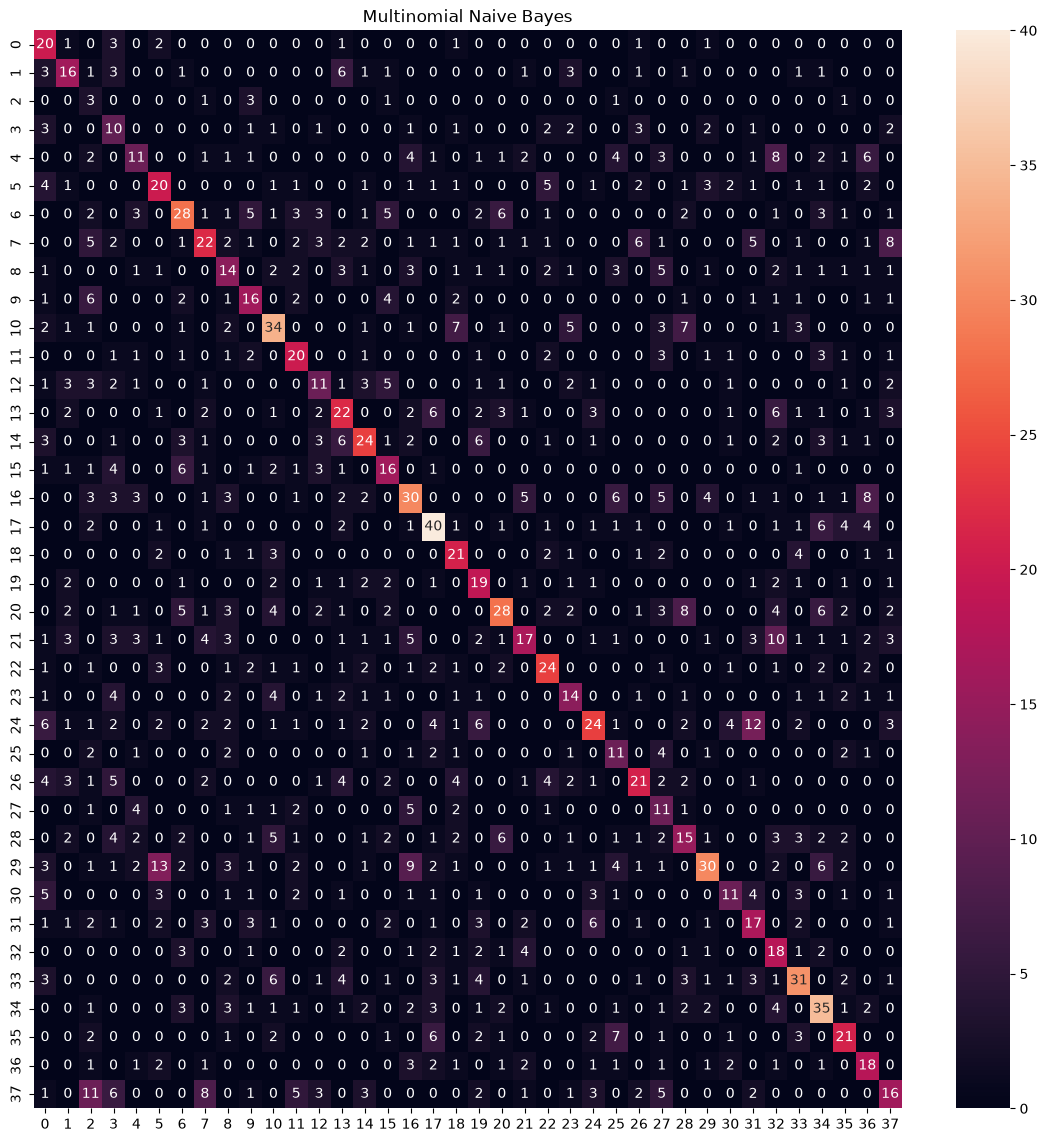

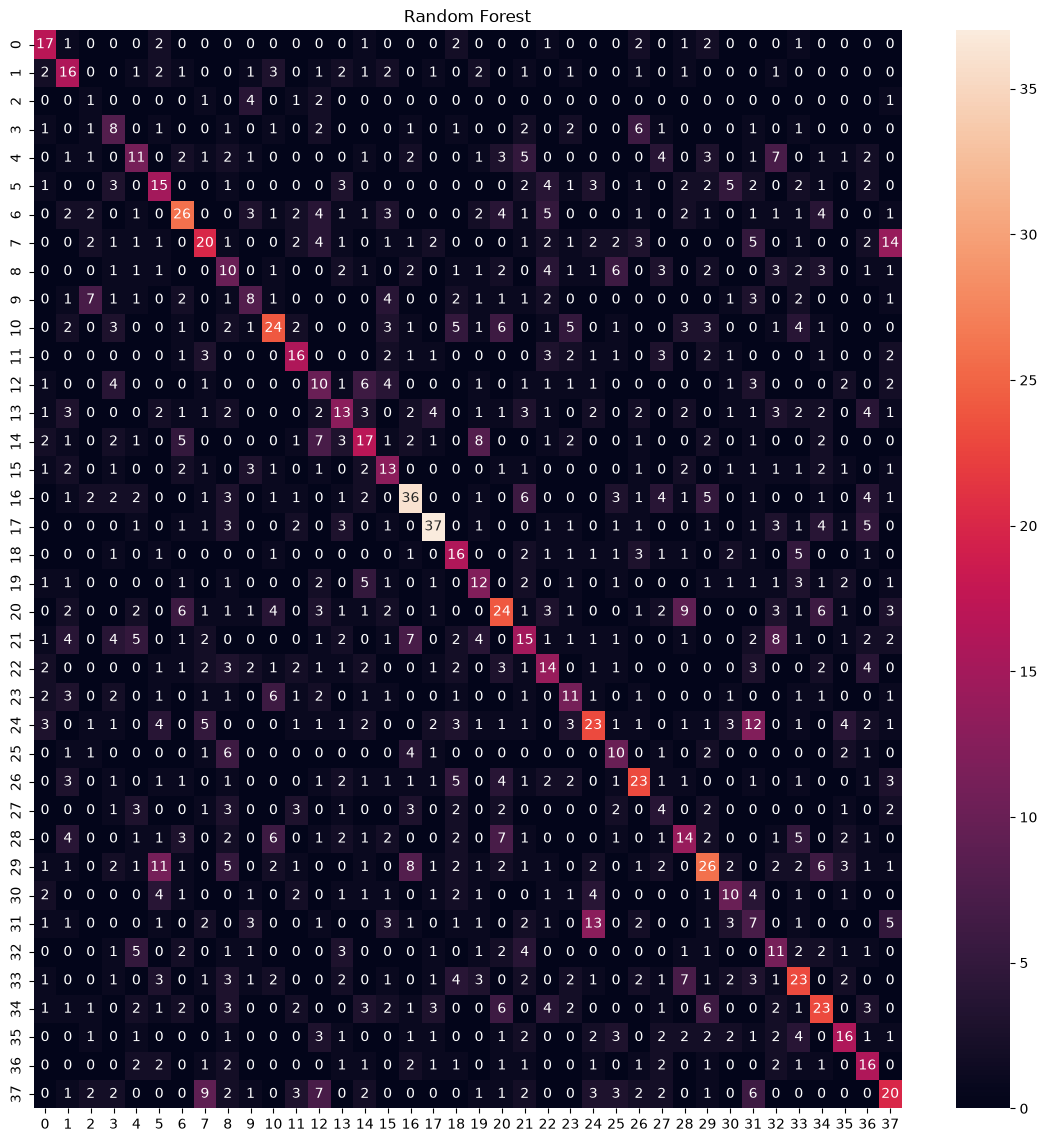

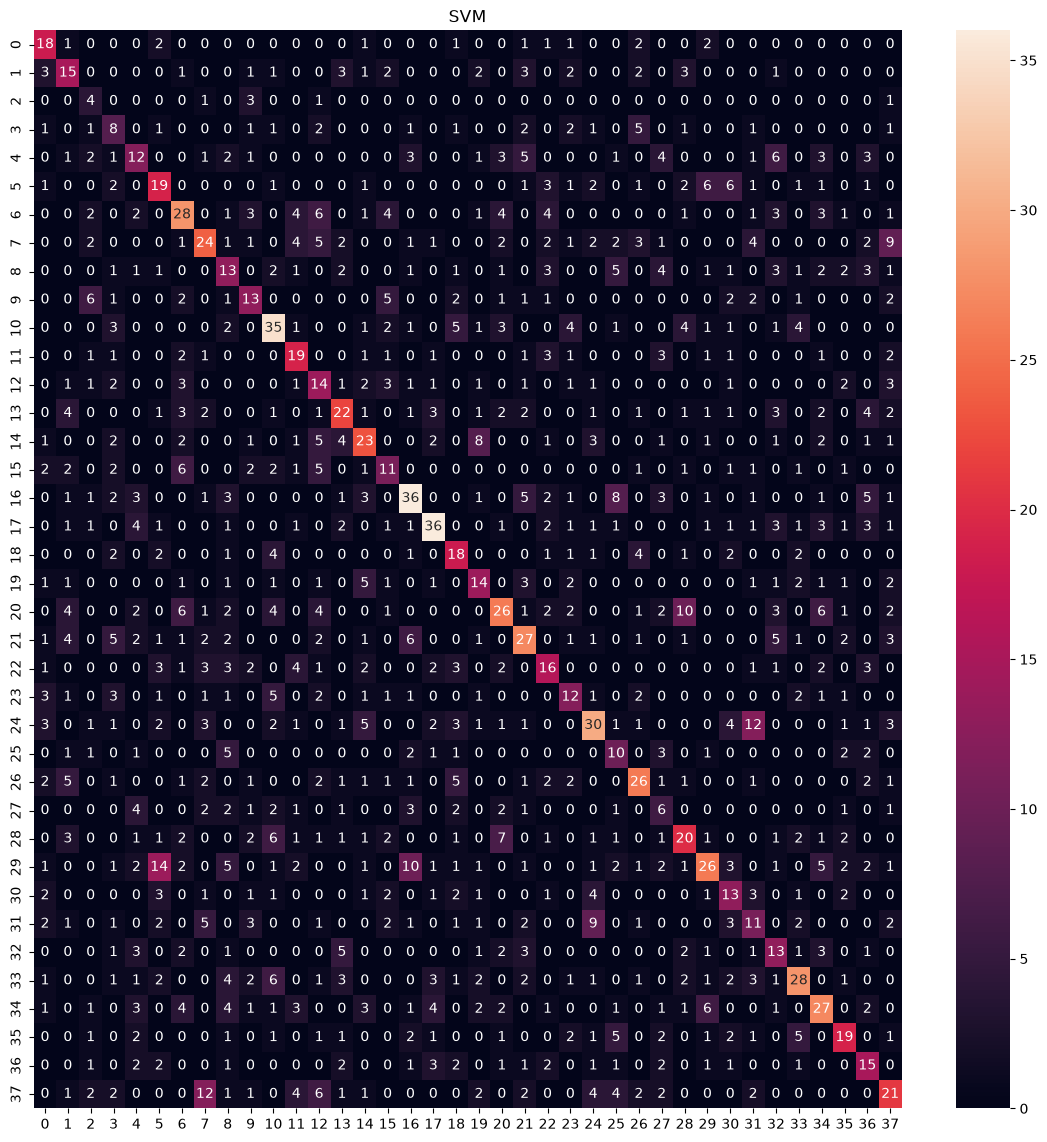

In [29]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
for model_name, model in models.items():
    pipe=make_pipeline(RandomOverSampler(random_state=42),model)
    try:
        y_pred=cross_val_predict(pipe,X,y,cv=skf)
        cm=confusion_matrix(y,y_pred)
        # disp=ConfusionMatrixDisplay(confusion_matrix=cm)
        # plt.figure(figsize=(16,16))
        # disp.plot(cmap=plt.cm.Blues,include_values=False)
        # plt.xticks(rotation=90)
        plt.figure(figsize=(14,14))
        sns.heatmap(cm,annot=True)
        plt.title(f"{model_name}")
        print(f"{model_name}\n{classification_report(y,y_pred)}")
    except Exception as e:
        print(f"Model:{model_name} failed with {e}")

In [30]:
symptoms=X.columns.values
# get column names
# X.values get the values except column name
symptom_index={symptom: idx for idx, symptom in enumerate (symptoms)}
# create a dictionary mapping symptom to integer index
print(symptom_index)

from statistics import mode,StatisticsError
# scipy.stats for numeric arrays and return a object holds res(ult).mode-most frequent value and res.count-times it appear
def predict_disease(input_symptoms):
    input_symptoms=[s.strip() for s in input_symptoms.split(",")]
    # split comma separated string into individual symptom string
    # remove leading/trailing whitespace 
    input_data=[0]*len(symptom_index)
    # create a list of zeros in length equal to number of symptom 
    for symptom in input_symptoms:
        if symptom in symptom_index:
            input_data[symptom_index[symptom]]=1
    # Loops through your input symptoms. If a symptom exists in your dataset's vocabulary, it flips that specific index from 0 to 1 (creating a binary presence/absence vector).
    input_df=pd.DataFrame([input_data],columns=symptoms)
    # wrap list into df 
    input_df.tail()
    predictions={}
    pred_list=[]
    for model_name, model in models.items():
        # make_pipeline is meant for chaining scikit-learn models/transformers together during training, not for managing custom evaluation functions like model.predict or encoder.classes_ during inference.
        # first model predict, then label decoding (encoder.classes_)
        try:
            pred_idx=model.predict(input_df)[0]
            # extract dataframe to number 
            pred_label=encoder.classes_[pred_idx]
            predictions[model_name]=pred_label
            pred_list.append(pred_label)
            print(f"{model_name} Prediction:{pred_label}")
        except Exception as e:
            print(f"{model_name} failed with {e}")

    if pred_list:
        # final_pred=mode(pipe)
        # ensemble voting(mode): statistical majority voting 
        # res=mode(pred_list,keepdims=True)
        # Using keepdims=True is a best practice in Python data science because it prevents shape mismatch errors later in your code.
        try:
            # final_pred=res.mode[0]
            # pick the first prediction when ties 
            final_pred=mode(pred_list)
        except StatisticsError:
            # like ties 
            final_pred=predictions.get("Multinomial Naive Bayes",pred_list[0])
            # pick first prediction as fallback
    else:
        final_pred="No predictions available"

    predictions['Final Prediction']=final_pred
    return predictions

print(predict_disease("skin_rash, fever, headache"))


{'fever': 0, 'headache': 1, 'nausea': 2, 'vomiting': 3, 'fatigue': 4, 'joint_pain': 5, 'skin_rash': 6, 'cough': 7, 'weight_loss': 8, 'yellow_eyes': 9}
Multinomial Naive Bayes Prediction:Pneumonia
Random Forest Prediction:Pneumonia
SVM Prediction:Pneumonia
{'Multinomial Naive Bayes': 'Pneumonia', 'Random Forest': 'Pneumonia', 'SVM': 'Pneumonia', 'Final Prediction': 'Pneumonia'}
